## Redes Neuronales Convolucionales con PyTorch

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt

In [4]:
def plot_history(history, figsize=(12, 4), title_suffix=''):
    required_keys = ['train_loss', 'val_loss', 'train_acc', 'val_acc']
    for key in required_keys:
        if key not in history:
            raise KeyError(f"Falta la llave '{key}' en history")

    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='train_loss')
    plt.plot(epochs_range, history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Loss por época {title_suffix}".strip())
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='train_acc')
    plt.plot(epochs_range, history['val_acc'], label='val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f"Accuracy por época {title_suffix}".strip())
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Descargar Cifar10 dataset

In [7]:
DATA_PATH = '../data/Databases/cifar-10-batches-py'
NUM_TRAIN = 50000
NUM_VAL = 5000
NUM_TEST = 5000
MINIBATCH_SIZE = 64

transform_cifar = T.Compose([
                T.ToTensor(),
                T.Normalize([0.491, 0.482, 0.447], [0.247, 0.243, 0.261])
            ])

# Train dataset
cifar10_train = datasets.CIFAR10(DATA_PATH, train=True, download=True,
                             transform=transform_cifar)
train_loader = DataLoader(cifar10_train, batch_size=MINIBATCH_SIZE, 
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))
#Validation set
cifar10_val = datasets.CIFAR10(DATA_PATH, train=False, download=True,
                           transform=transform_cifar)
val_loader = DataLoader(cifar10_val, batch_size=MINIBATCH_SIZE, 
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL)))
#Test set
cifar10_test = datasets.CIFAR10(DATA_PATH, train=False, download=True, 
                            transform=transform_cifar)
test_loader = DataLoader(cifar10_test, batch_size=MINIBATCH_SIZE,
                        sampler=sampler.SubsetRandomSampler(range(NUM_VAL, NUM_VAL + NUM_TEST)))

c:\Users\jose.rodriguezb\Desktop\Proyecto-I-Clasificador-Imagenes\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [8]:
cifar10_train

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../data/Databases/cifar-10-batches-py
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.491, 0.482, 0.447], std=[0.247, 0.243, 0.261])
           )

### Usar GPUs

In [9]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(device)

cuda


### Mostrar imágenes

La imagen muestreada representa un: airplane


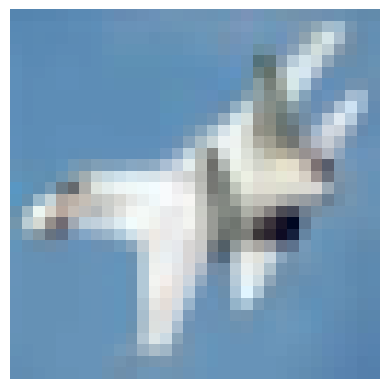

In [10]:
classes = test_loader.dataset.classes
def plot_figure(image):
    plt.imshow(np.transpose(image,(1,2,0)))
    plt.axis('off')
    plt.show()

rnd_sample_idx = np.random.randint(len(test_loader))
print(f'La imagen muestreada representa un: {classes[test_loader.dataset[rnd_sample_idx][1]]}')
image = test_loader.dataset[rnd_sample_idx][0]
image = (image - image.min()) / (image.max() -image.min() )
plot_figure(image)


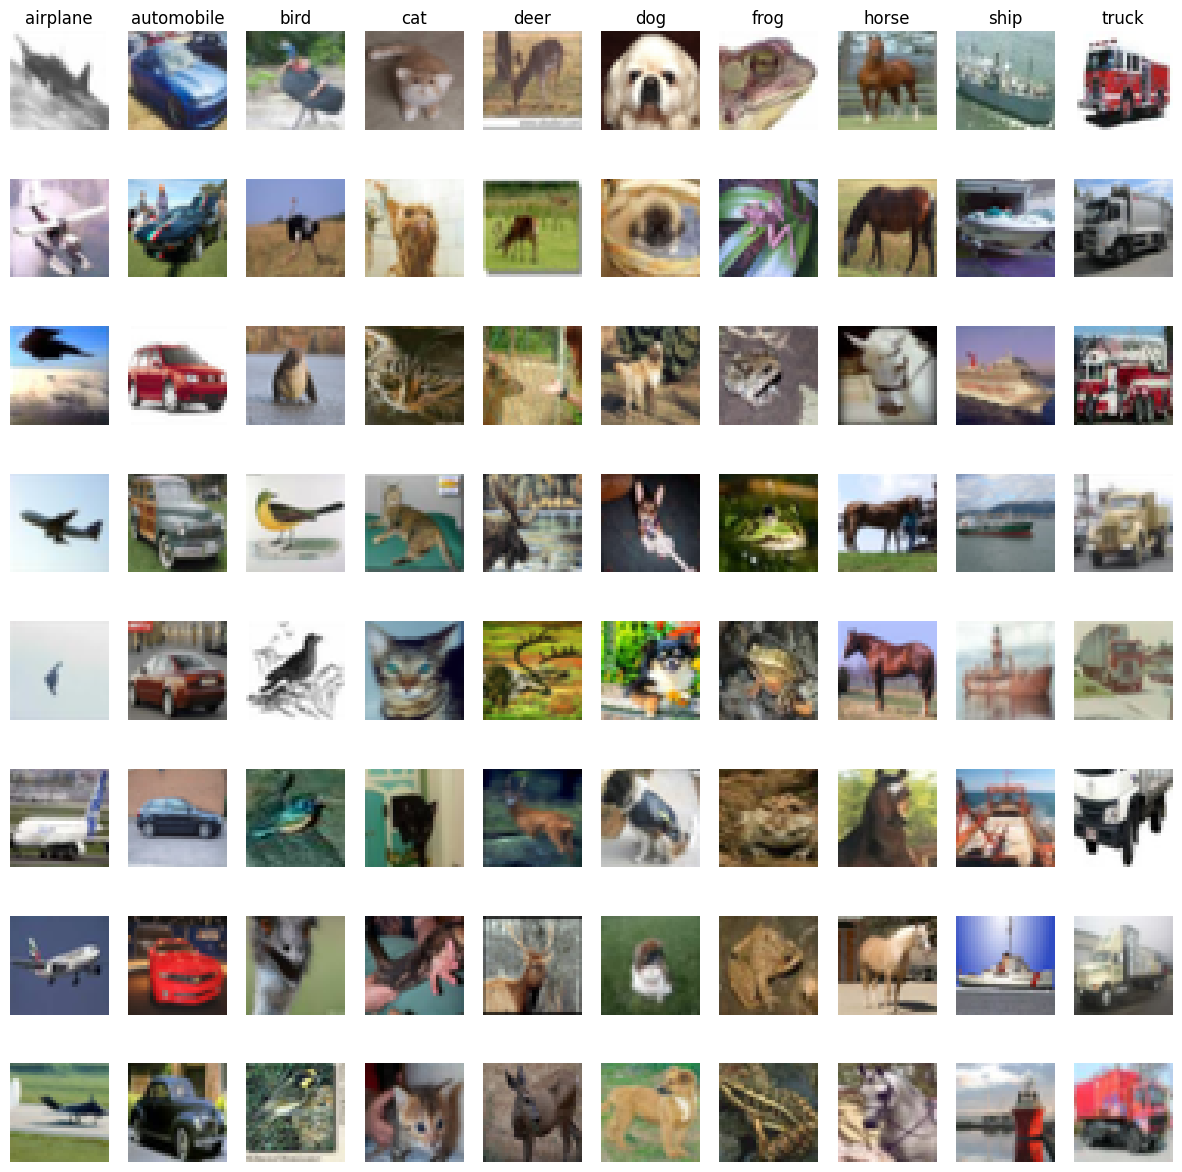

In [11]:
def plot_cifar10_grid():
    classes = test_loader.dataset.classes
    total_samples = 8
    plt.figure(figsize=(15,15))
    for label, sample in enumerate(classes):
        class_idxs = np.flatnonzero(label == np.array(test_loader.dataset.targets))
        sample_idxs = np.random.choice(class_idxs, total_samples, replace = False)
        for i, idx in enumerate(sample_idxs):
            plt_idx = i*len(classes) + label + 1
            plt.subplot(total_samples, len(classes), plt_idx)
            plt.imshow(test_loader.dataset.data[idx])
            plt.axis('off')
            
            if i == 0: plt.title(sample)
    plt.show()

plot_cifar10_grid() 

### Calcular accuracy y loss


In [12]:
def evaluate(model, loader):
    num_correct = 0
    num_total = 0
    total_loss = 0.0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for xi, yi in loader:
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)
            loss = F.cross_entropy(scores, yi)
            _, pred = scores.max(dim=1)
            num_correct += (pred == yi).sum().item()
            num_total += yi.size(0)
            total_loss += loss.item() * yi.size(0)
    acc = num_correct / num_total
    avg_loss = total_loss / num_total
    return acc, avg_loss

### Loop de entrenamiento

In [13]:
def train(model, optimiser, epochs=100):
    model = model.to(device=device)
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(epochs):
        model = model.to(device=device)
        for i, (xi, yi) in enumerate(train_loader):
            model.train()
            xi = xi.to(device=device, dtype=torch.float32)
            yi = yi.to(device=device, dtype=torch.long)
            scores = model(xi)
            cost = F.cross_entropy(input=scores, target=yi)

            optimiser.zero_grad()
            cost.backward()
            optimiser.step()

        train_acc, train_loss = evaluate(model, train_loader)
        val_acc, val_loss = evaluate(model, val_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch: {epoch+1}/{epochs} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

    return history

### Sequential linear

In [10]:
hidden1 = 256 
hidden = 256
lr = 0.001
epochs = 10
model1 = nn.Sequential(nn.Flatten(),
                       nn.Linear(in_features=32*32*3, out_features=hidden1), nn.ReLU(),
                       nn.Linear(in_features=hidden1, out_features=hidden), nn.ReLU(),
                       nn.Linear(in_features=hidden, out_features=10))
optimiser = torch.optim.Adam(model1.parameters(), lr=lr)

Epoch: 1/10 | train_loss: 1.4970 | train_acc: 0.4710 | val_loss: 1.5333 | val_acc: 0.4564
Epoch: 2/10 | train_loss: 1.3457 | train_acc: 0.5289 | val_loss: 1.4429 | val_acc: 0.4892
Epoch: 3/10 | train_loss: 1.2243 | train_acc: 0.5682 | val_loss: 1.3857 | val_acc: 0.5210
Epoch: 4/10 | train_loss: 1.1453 | train_acc: 0.5958 | val_loss: 1.3936 | val_acc: 0.5156
Epoch: 5/10 | train_loss: 1.1258 | train_acc: 0.5999 | val_loss: 1.4206 | val_acc: 0.5148
Epoch: 6/10 | train_loss: 1.0260 | train_acc: 0.6354 | val_loss: 1.4095 | val_acc: 0.5196
Epoch: 7/10 | train_loss: 0.9636 | train_acc: 0.6574 | val_loss: 1.3990 | val_acc: 0.5336
Epoch: 8/10 | train_loss: 0.9097 | train_acc: 0.6776 | val_loss: 1.4741 | val_acc: 0.5332
Epoch: 9/10 | train_loss: 0.8357 | train_acc: 0.7021 | val_loss: 1.4929 | val_acc: 0.5336
Epoch: 10/10 | train_loss: 0.8052 | train_acc: 0.7139 | val_loss: 1.5137 | val_acc: 0.5224


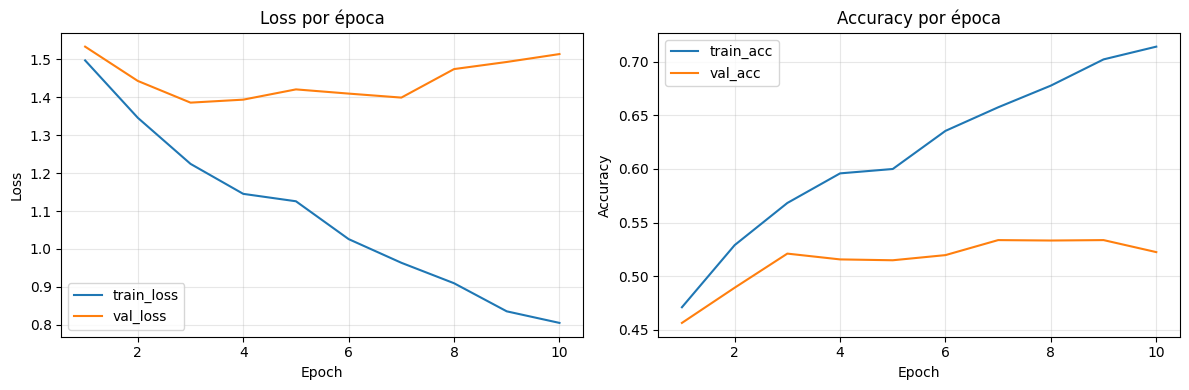

CPU times: total: 1min 32s
Wall time: 4min 35s


In [11]:
%%time
history = train(model1, optimiser, epochs)
plot_history(history)

### Sequential CNN

In [12]:
channel1 = 16
channel2 = 32
epochs = 10
lr = 0.001
modelCNN1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=channel1, 
                kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=channel1, out_channels=channel2,
                kernel_size= 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),
        nn.Flatten(),
        nn.Linear(in_features=16*16*channel2, out_features=10)                        
)
optimiser = torch.optim.Adam(modelCNN1.parameters(), lr)

In [13]:
%%time
history = train(modelCNN1, optimiser, epochs)

Epoch: 1/10 | train_loss: 1.0457 | train_acc: 0.6387 | val_loss: 1.1197 | val_acc: 0.6094
Epoch: 2/10 | train_loss: 0.8355 | train_acc: 0.7137 | val_loss: 0.9737 | val_acc: 0.6698
Epoch: 3/10 | train_loss: 0.7165 | train_acc: 0.7580 | val_loss: 0.9461 | val_acc: 0.6704
Epoch: 4/10 | train_loss: 0.6433 | train_acc: 0.7803 | val_loss: 0.9706 | val_acc: 0.6722
Epoch: 5/10 | train_loss: 0.5758 | train_acc: 0.8096 | val_loss: 0.9745 | val_acc: 0.6748
Epoch: 6/10 | train_loss: 0.5080 | train_acc: 0.8304 | val_loss: 1.0121 | val_acc: 0.6716
Epoch: 7/10 | train_loss: 0.4600 | train_acc: 0.8484 | val_loss: 1.0624 | val_acc: 0.6706
Epoch: 8/10 | train_loss: 0.4120 | train_acc: 0.8659 | val_loss: 1.1001 | val_acc: 0.6732
Epoch: 9/10 | train_loss: 0.3720 | train_acc: 0.8795 | val_loss: 1.1620 | val_acc: 0.6622
Epoch: 10/10 | train_loss: 0.3291 | train_acc: 0.8936 | val_loss: 1.2393 | val_acc: 0.6656
CPU times: total: 1min 44s
Wall time: 6min 11s


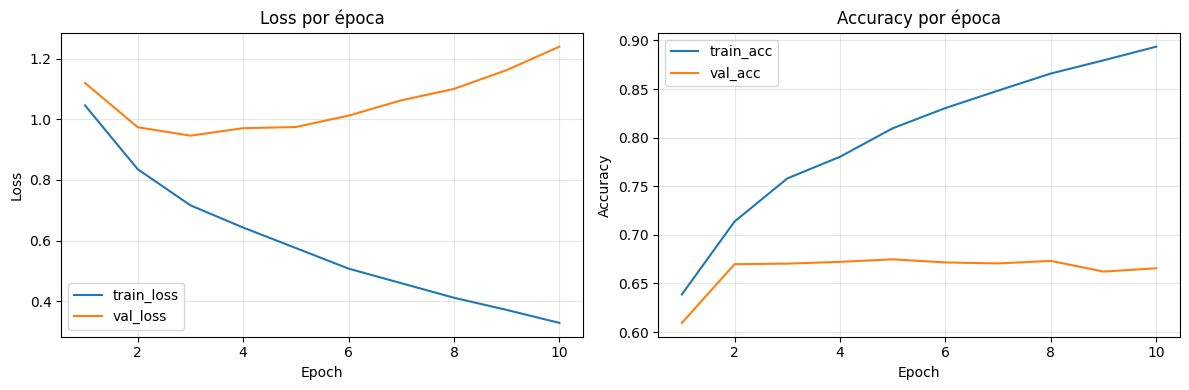

In [14]:
plot_history(history)

### OOP (Programación orientada a objetos)

In [15]:
class CNN_class1(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = in_channel, out_channels = channel1,
                              kernel_size=3, padding = 1)
        self.conv2 = nn.Conv2d(in_channels = channel1, out_channels = channel2,
                              kernel_size=3, padding=1)
        self.max_pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(in_features=16*16*channel2, out_features=10)
        self.flatten = nn.Flatten()
    def forward(self, x):
        x = F.relu(self.conv2(F.relu(self.conv1(x))))
        x = self.max_pool(x)
        x = self.flatten(x)
        return self.fc(x)

In [16]:
channel1 = 16
channel2 = 32
epochs = 10
lr = 0.001
modelCNN2 = CNN_class1(3, channel1, channel2)
optimiser = torch.optim.Adam(modelCNN2.parameters(), lr)

In [17]:
%%time
history = train(modelCNN2, optimiser, epochs)

Epoch: 1/10 | train_loss: 0.9816 | train_acc: 0.6636 | val_loss: 1.0511 | val_acc: 0.6254
Epoch: 2/10 | train_loss: 0.8545 | train_acc: 0.7055 | val_loss: 1.0135 | val_acc: 0.6498
Epoch: 3/10 | train_loss: 0.7381 | train_acc: 0.7482 | val_loss: 0.9632 | val_acc: 0.6660
Epoch: 4/10 | train_loss: 0.6237 | train_acc: 0.7897 | val_loss: 0.9524 | val_acc: 0.6732
Epoch: 5/10 | train_loss: 0.5745 | train_acc: 0.8092 | val_loss: 0.9825 | val_acc: 0.6722
Epoch: 6/10 | train_loss: 0.5512 | train_acc: 0.8109 | val_loss: 1.0506 | val_acc: 0.6664
Epoch: 7/10 | train_loss: 0.4641 | train_acc: 0.8437 | val_loss: 1.0886 | val_acc: 0.6590
Epoch: 8/10 | train_loss: 0.4228 | train_acc: 0.8602 | val_loss: 1.1256 | val_acc: 0.6554
Epoch: 9/10 | train_loss: 0.3749 | train_acc: 0.8780 | val_loss: 1.1965 | val_acc: 0.6548
Epoch: 10/10 | train_loss: 0.3222 | train_acc: 0.9003 | val_loss: 1.2163 | val_acc: 0.6604
CPU times: total: 2min 55s
Wall time: 7min 33s


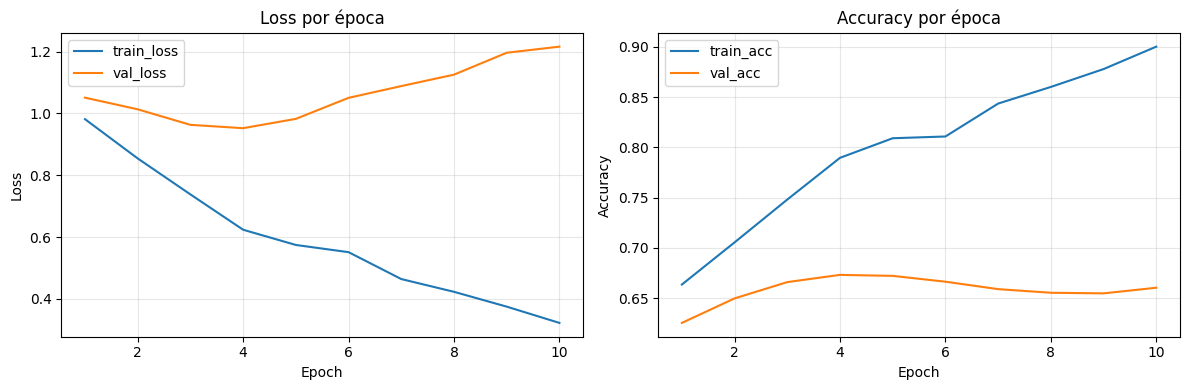

In [18]:
plot_history(history)

### Otra forma

In [16]:
conv_k_3 = lambda channel1, channel2: nn.Conv2d(channel1, channel2, kernel_size=3, padding=1)

In [20]:
class CNN_class2(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = conv_k_3(in_channel, channel1)
        nn.init.kaiming_uniform_(self.conv1.weight)

        self.conv2 = conv_k_3(channel1, channel2)
        self.max_pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(in_features=16*16*channel2, out_features=10)
        self.flatten = nn.Flatten()
    def forward(self, x):
        x = F.relu(self.conv2(F.relu(self.conv1(x))))
        x = self.max_pool(x)
        x = self.flatten(x)
        return self.fc(x)
    

In [21]:
channel1 = 16
channel2 = 32
epochs = 10
lr = 0.001
modelCNN3 = CNN_class2(3, channel1, channel2)
optimiser = torch.optim.Adam(modelCNN3.parameters(), lr)

In [22]:
%%time
history = train(modelCNN3, optimiser, epochs)

Epoch: 1/10 | train_loss: 0.9354 | train_acc: 0.6801 | val_loss: 1.0365 | val_acc: 0.6452
Epoch: 2/10 | train_loss: 0.7849 | train_acc: 0.7338 | val_loss: 0.9919 | val_acc: 0.6624
Epoch: 3/10 | train_loss: 0.6831 | train_acc: 0.7729 | val_loss: 0.9675 | val_acc: 0.6696
Epoch: 4/10 | train_loss: 0.6026 | train_acc: 0.7930 | val_loss: 1.0092 | val_acc: 0.6616
Epoch: 5/10 | train_loss: 0.5212 | train_acc: 0.8270 | val_loss: 1.0347 | val_acc: 0.6636
Epoch: 6/10 | train_loss: 0.4402 | train_acc: 0.8557 | val_loss: 1.0537 | val_acc: 0.6634
Epoch: 7/10 | train_loss: 0.4163 | train_acc: 0.8633 | val_loss: 1.1186 | val_acc: 0.6600
Epoch: 8/10 | train_loss: 0.3639 | train_acc: 0.8771 | val_loss: 1.2461 | val_acc: 0.6556
Epoch: 9/10 | train_loss: 0.3246 | train_acc: 0.8957 | val_loss: 1.2515 | val_acc: 0.6586
Epoch: 10/10 | train_loss: 0.3100 | train_acc: 0.8947 | val_loss: 1.3859 | val_acc: 0.6386
CPU times: total: 2min 58s
Wall time: 7min 20s


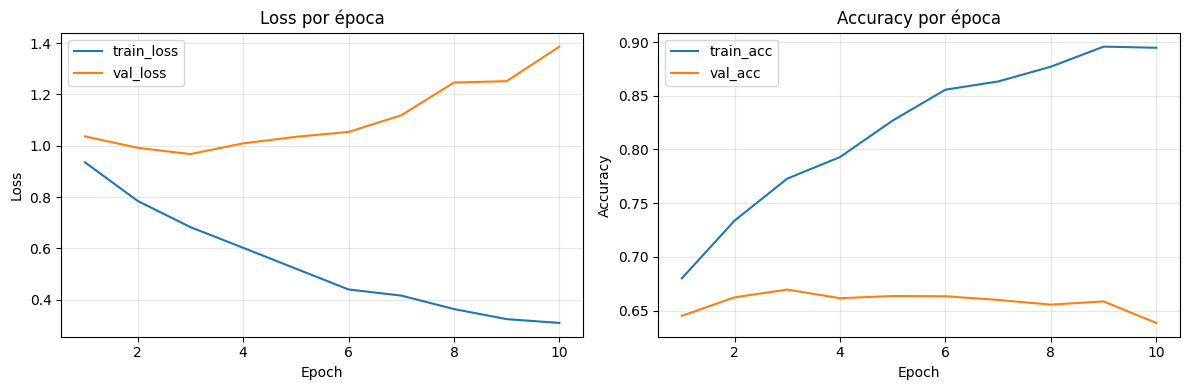

In [23]:
plot_history(history)

In [14]:
class CNN_class3(nn.Module):
    def __init__(self, in_channel, channel1, channel2):
        super().__init__()
        self.conv1 = conv_k_3(in_channel, channel1)
        self.bn1 = nn.BatchNorm2d(channel1, momentum=0.01)

        self.conv2 = conv_k_3(channel1, channel2)
        self.bn2 = nn.BatchNorm2d(channel2, momentum=0.01)
        
        self.max_pool = nn.MaxPool2d(2,2)
        

    def forward(self, x):
        x = F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))))
        return self.max_pool(x)

In [17]:
channel1 = 32
channel2 = 64
channel3 = 128
channel4 = 64
epochs = 20
lr = 0.001
modelCNN4 = nn.Sequential(
        CNN_class3(3,channel1, channel2),
        CNN_class3(channel2, channel4, channel4),
        
        nn.Flatten(),

        # Nueva Capa Densa Intermedia
        nn.Linear(in_features=8*8*channel4, out_features=128), # Capa oculta
        nn.ReLU(),                                             # Activación
        nn.Dropout(p=0.5),                                     # Regularización para 
                                                               # evitar overfitting

        # Capa de Clasificación Final
        nn.Linear(in_features=128, out_features=10)
)
optimiser = torch.optim.Adam(modelCNN4.parameters(), lr, weight_decay=1e-4)

Epoch: 1/20 | train_loss: 1.4401 | train_acc: 0.4667 | val_loss: 1.4415 | val_acc: 0.4670
Epoch: 2/20 | train_loss: 0.9746 | train_acc: 0.6536 | val_loss: 1.0096 | val_acc: 0.6480
Epoch: 3/20 | train_loss: 0.8947 | train_acc: 0.6710 | val_loss: 0.9551 | val_acc: 0.6490
Epoch: 4/20 | train_loss: 0.9218 | train_acc: 0.6713 | val_loss: 0.9871 | val_acc: 0.6640
Epoch: 5/20 | train_loss: 0.7251 | train_acc: 0.7530 | val_loss: 0.7977 | val_acc: 0.7260
Epoch: 6/20 | train_loss: 0.8106 | train_acc: 0.7158 | val_loss: 0.9164 | val_acc: 0.6878
Epoch: 7/20 | train_loss: 0.6657 | train_acc: 0.7708 | val_loss: 0.7699 | val_acc: 0.7372
Epoch: 8/20 | train_loss: 0.6048 | train_acc: 0.7971 | val_loss: 0.7359 | val_acc: 0.7566
Epoch: 9/20 | train_loss: 0.5748 | train_acc: 0.8032 | val_loss: 0.7328 | val_acc: 0.7618
Epoch: 10/20 | train_loss: 0.7006 | train_acc: 0.7497 | val_loss: 0.8706 | val_acc: 0.7100
Epoch: 11/20 | train_loss: 0.5150 | train_acc: 0.8231 | val_loss: 0.7218 | val_acc: 0.7676
Epoch: 1

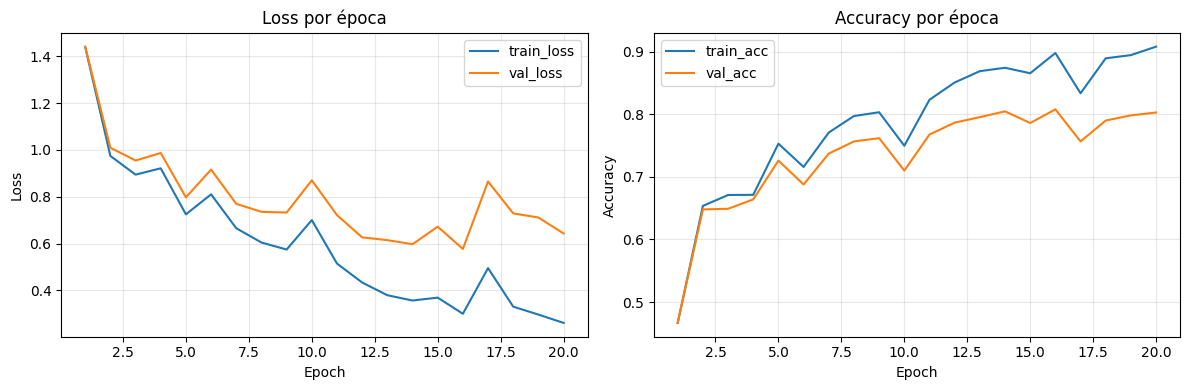

CPU times: total: 6min 8s
Wall time: 17min 54s


In [18]:
%%time
history = train(modelCNN4, optimiser, epochs)
plot_history(history)

In [19]:
test_acc, _ = evaluate(modelCNN4, test_loader)
print(f'test_acc: {test_acc:.4f}')

test_acc: 0.7976
